In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
dfpaises = pd.read_csv('../Matplotlib/paises.csv', sep=';')
dfspace = pd.read_csv('../Matplotlib/space.csv', sep=';')

Questão 01:

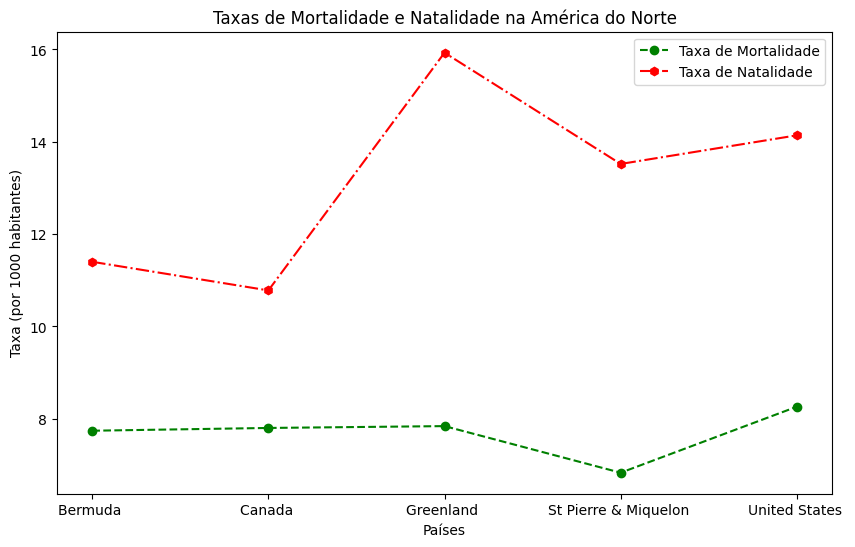

In [7]:
import matplotlib.pyplot as plt
import pandas as pd

# Obtem apenas os países da América do Norte
df = dfpaises[dfpaises["Region"].str.contains("NORTHERN AMERICA", case=False)]

# Definir os eixos X (Países) e Y (Mortalidade e Natalidade) usando o DataFrame filtrado
x = df["Country"]
y_mortalidade = df["Deathrate"]
y_natalidade = df["Birthrate"]

plt.figure(figsize=(10, 6))

# Traçar as duas linhas no mesmo plano cartesiano
plt.plot(x, y_mortalidade, "g--o", label="Taxa de Mortalidade")
plt.plot(x, y_natalidade, "r-.h", label="Taxa de Natalidade")

plt.title("Taxas de Mortalidade e Natalidade na América do Norte")
plt.xlabel("Países")
plt.ylabel("Taxa (por 1000 habitantes)")
plt.legend()

plt.show()

Questão 02:

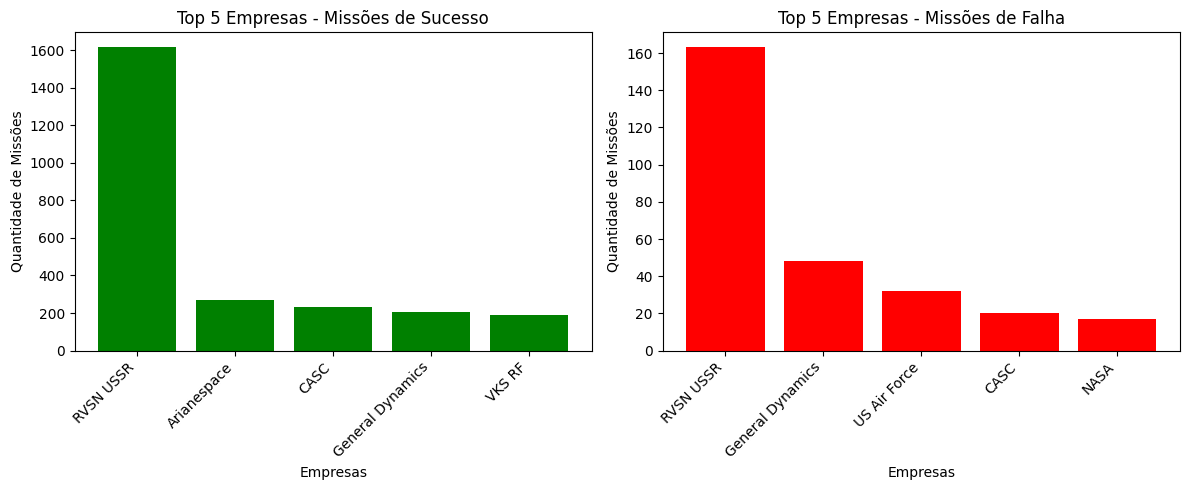

In [10]:
dfsuccess = dfspace[dfspace["Status Mission"].str.contains("SUCCESS", case=False)]
dflailure = dfspace[dfspace["Status Mission"].str.contains("FAILURE", case=False)]

# Conta as missões por empresa e pegar as 5 maiores de cada categoria
top_success = dfsuccess["Company Name"].value_counts().head(5)
top_failure = dflailure["Company Name"].value_counts().head(5)

# Configurar o tamanho geral da janela dos gráficos
plt.figure(figsize=(12, 5))

# Gráfico da Esquerda: Sucesso
plt.subplot(1, 2, 1)
plt.bar(top_success.index, top_success.values, color="green")
plt.title("Top 5 Empresas - Missões de Sucesso")
plt.xlabel("Empresas")
plt.ylabel("Quantidade de Missões")
plt.xticks(rotation=45, ha="right")

# Gráfico da Direita: Falha
plt.subplot(1, 2, 2)
plt.bar(top_failure.index, top_failure.values, color="red")
plt.title("Top 5 Empresas - Missões de Falha")
plt.xlabel("Empresas")
plt.ylabel("Quantidade de Missões")
plt.xticks(rotation=45, ha="right")  # Rotaciona os nomes para não embolar

# Ajusta o espaçamento e exibe
plt.tight_layout()
plt.show()

Questão 03:

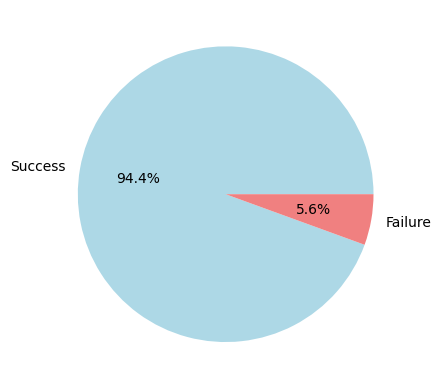

In [16]:
# Filtra as missões apenas da empresa Roscosmos
df_roscosmos = dfspace[dfspace["Company Name"].str.strip() == "Roscosmos"]

# Cria o filtro para o status de sucesso
filter = df_roscosmos["Status Mission"].str.strip() == "Success"

sucesso = df_roscosmos[filter]

# Quantidade de missões que deram certo (Success)
qtSuccess = len(sucesso)
# Quantidade de missões que deram errado (Failure)
df_validas = df_roscosmos[
    df_roscosmos["Status Mission"].str.strip().isin(["Success", "Failure"])
]
qtFailure = len(df_validas) - qtSuccess

plt.pie(
    [qtSuccess, qtFailure],
    labels=["Success", "Failure"],
    autopct="%1.1f%%",
    colors=["lightblue", "lightcoral"],
)

plt.show()

Questão 04:

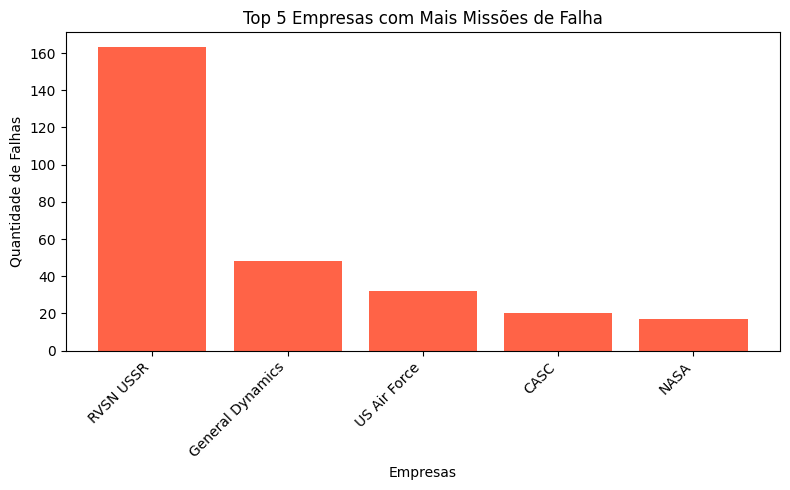

In [17]:
# Filtrar apenas as missões que falharam
dffailures = dfspace[dfspace["Status Mission"].str.contains("FAILURE", case=False)]

# Contar as falhas por empresa e pegar as 5 primeiras
top_failures = dffailures["Company Name"].value_counts().head(5)

# Gerar o gráfico de barras com uma cor customizada
plt.figure(figsize=(8, 5))
plt.bar(top_failures.index, top_failures.values, color="#FF6347")

plt.title("Top 5 Empresas com Mais Missões de Falha")
plt.xlabel("Empresas")
plt.ylabel("Quantidade de Falhas")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()


Questão 05:

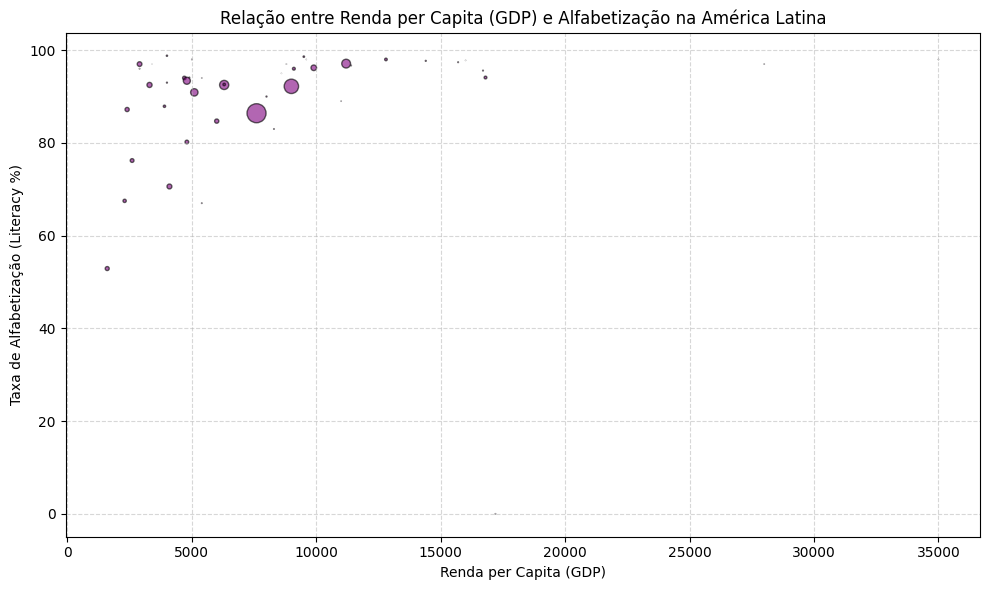

In [ ]:
# Remove os espaços em branco invisíveis no início e fim de todas as colunas do arquivo
dfpaises.columns = dfpaises.columns.str.strip()

# Filtrar países da América Latina
dflatam = dfpaises[dfpaises["Region"].str.contains("LATIN AMER", case=False)].copy()

# Garantir que as colunas numéricas estejam convertidas corretamente (remove vírgulas)
dflatam["GDP ($ per capita)"] = (
    dflatam["GDP ($ per capita)"]
    .astype(str)
    .str.replace(",", ".")
    .astype(float)
)
dflatam["Literacy (%)"] = (dflatam["Literacy (%)"].astype(str).str.replace(",", ".").astype(float))
dflatam["Population"] = (dflatam["Population"].astype(str).str.replace(",", ".").astype(float))

# Definir as variáveis do gráfico
x = dflatam["GDP ($ per capita)"]
y = dflatam["Literacy (%)"]

# Definir o tamanho dos pontos proporcional à população
tamanho_pontos = dflatam["Population"] / 1000000

# 4. Construir o gráfico de dispersão (Scatter)
plt.figure(figsize=(10, 6))
plt.scatter(
    x,
    y,
    s=tamanho_pontos,
    alpha=0.6,
    c="purple",
    edgecolors="black",
)

plt.title("Relação entre Renda per Capita (GDP) e Alfabetização na América Latina")
plt.xlabel("Renda per Capita (GDP)")
plt.ylabel("Taxa de Alfabetização (Literacy %)")
plt.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()